In [1]:
import sys
sys.path.append(r'C:\Users\Manu\secureflow_analytics\src')

import config

# Check paths
print("=" * 60)
print("SecureFlow Analytics - Setup Verification")
print("=" * 60)

# Validate
if config.validate_paths():
    print("\n✅ Setup complete! Ready to run notebooks.")
else:
    print("\n❌ Setup incomplete. Check errors above.")

SecureFlow Analytics - Setup Verification
✅ All paths validated!
   Project: C:\Users\Manu\secureflow_analytics
   Data: C:\Users\Manu\secureflow_analytics\data\raw
   - users.parquet: 0.5 MB
   - events.parquet: 555.2 MB
   - subscriptions.parquet: 0.9 MB
   Total: 556.6 MB

✅ Setup complete! Ready to run notebooks.


In [2]:
import duckdb
import config

# Test connection
con = duckdb.connect()

# Test query
test_query = f"SELECT COUNT(*) FROM read_parquet('{config.EVENTS_FILE}')"
result = con.execute(test_query).fetchone()

print(f"✅ Events count: {result[0]:,}")
con.close()

✅ Events count: 29,126,215


# SecureFlow Analytics - Phase 1: EDA & Data Validation

**Objective:** Explore and validate the synthetic data, confirm embedded patterns exist.

**Sections:**
1. Setup & Data Loading
2. Data Quality Assessment
3. User Analysis
4. Event Analysis (via DuckDB)
5. Subscription Analysis
6. Experiment Coverage
7. Pattern Validation (Embedded Insights)
8. Key Findings Summary

## 1. Setup & Data Loading

In [3]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import duckdb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded")

Libraries loaded


In [4]:
# Add project root to path
import sys
PROJECT_ROOT = Path.cwd().parent  # Assumes running from notebooks/
sys.path.insert(0, str(PROJECT_ROOT))

# Import data loader functions from utils
from src.utils import (
    load_table,
    load_all_tables,
    get_table_info,
    query_events,
    query_raw_table,
    execute_query,
    get_connection,
)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\Manu\secureflow_analytics


In [5]:
# Get DuckDB connection
con = get_connection(memory_only=True)

# Load all tables (excluding events - too large for memory)
print("Loading data tables...")
data = load_all_tables(con, exclude_events=True)

print(f"\n✅ Data loaded successfully!")

Loading data tables...
  ✓ Loaded users: 50,000 rows
  ✓ Loaded subscriptions: 50,000 rows
  ✓ Loaded experiments: 4 rows
  ✓ Loaded experiment_assignments: 36,711 rows
  ✓ Loaded experiment_metrics: 36,711 rows
  ✓ Loaded feature_usage: 113,346 rows
  ✓ Loaded support_tickets: 35,175 rows

✅ Data loaded successfully!


In [6]:
# Unpack for convenience
users = data['users']
subscriptions = data['subscriptions']
experiments = data['experiments']
exp_assignments = data['experiment_assignments']
exp_metrics = data['experiment_metrics']
feature_usage = data['feature_usage']
support_tickets = data['support_tickets']

# Events handled via DuckDB queries (too large for memory)
import config
events_count = con.execute(f"SELECT COUNT(*) FROM read_parquet('{config.EVENTS_FILE}')").fetchone()[0]
print(f"\nEvents table: {events_count:,} rows (query via DuckDB)")


Events table: 29,126,215 rows (query via DuckDB)


In [7]:
# Table summary
get_table_info(data)

""


## 2. Data Quality Assessment

In [8]:
def check_data_quality(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Generate data quality report for a DataFrame."""
    report = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.values,
        'non_null': df.count().values,
        'null_count': df.isnull().sum().values,
        'null_pct': (df.isnull().sum() / len(df) * 100).values,
        'unique': df.nunique().values
    })
    print(f"\n{'='*60}")
    print(f"{name.upper()} - {len(df):,} rows, {len(df.columns)} columns")
    print(f"{'='*60}")
    return report

In [9]:
# Quality check for each table
for name, df in data.items():
    report = check_data_quality(df, name)
    display(report)


USERS - 50,000 rows, 7 columns


,column,dtype,non_null,null_count,null_pct,unique
0,user_id,object,50000,0,0.00,50000
1,signup_date,object,50000,0,0.00,516
2,plan_type,object,50000,0,0.00,3
3,country,object,50000,0,0.00,10
4,device_os,object,50000,0,0.00,4
5,acquisition_channel,object,50000,0,0.00,7
6,email_domain,object,50000,0,0.00,5



SUBSCRIPTIONS - 50,000 rows, 8 columns


,column,dtype,non_null,null_count,null_pct,unique
0,subscription_id,object,50000,0,0.00,50000
1,user_id,object,50000,0,0.00,50000
2,plan,object,50000,0,0.00,3
3,start_date,object,50000,0,0.00,516
4,end_date,object,50000,0,0.00,537
5,status,object,50000,0,0.00,2
6,mrr,float64,50000,0,0.00,3
7,cancellation_reason,object,6518,43482,86.96,4



EXPERIMENTS - 4 rows, 9 columns


...

,column,dtype,non_null,null_count,null_pct,unique
0,experiment_id,object,36711,0,0.00,4
1,user_id,object,36711,0,0.00,34414
2,metric_name,object,36711,0,0.00,4
3,metric_value,int64,36711,0,0.00,2
4,recorded_at,object,36711,0,0.00,365



FEATURE_USAGE - 113,346 rows, 5 columns


,column,dtype,non_null,null_count,null_pct,unique
0,user_id,object,113346,0,0.00,48105
1,feature_name,object,113346,0,0.00,8
2,first_used_at,object,113346,0,0.00,545
3,usage_count,int64,113346,0,0.00,147
4,last_used_at,object,113346,0,0.00,541



SUPPORT_TICKETS - 35,175 rows, 7 columns


,column,dtype,non_null,null_count,null_pct,unique
0,ticket_id,object,35175,0,0.00,35175
1,user_id,object,35175,0,0.00,18259
2,created_at,object,35175,0,0.00,544
3,category,object,35175,0,0.00,5
4,priority,object,35175,0,0.00,3
5,resolution_hours,int64,35175,0,0.00,186
6,csat_score,int64,35175,0,0.00,5


In [11]:
# Events quality check via DuckDB
print("\n" + "="*60)
print(f"EVENTS - {events_count:,} rows (via DuckDB)")
print("="*60)

events_sample = query_raw_table(con, 'events', limit=5)
print("\nSample:")
display(events_sample)


EVENTS - 29,126,215 rows (via DuckDB)

Sample:


,event_id,user_id,timestamp,event_type,properties,session_id,device_os,app_version
0,evt_0000000000,user_000000,2024-05-10 20:28:00,app_open,{},sess_user_000000_20240510,ios,3.1.0
1,evt_0000000001,user_000000,2024-06-05 22:26:00,share_clicked,{},sess_user_000000_20240605,ios,3.1.0
2,evt_0000000002,user_000000,2024-04-21 09:44:00,threat_resolved,{},sess_user_000000_20240421,ios,3.1.0
3,evt_0000000003,user_000000,2024-04-16 17:19:00,upgrade_clicked,{},sess_user_000000_20240416,ios,3.1.0
4,evt_0000000004,user_000000,2024-05-27 13:32:00,app_open,{},sess_user_000000_20240527,ios,3.1.0


In [12]:
# Check for duplicates
print("Duplicate Check:")
print(f"  Users (user_id):        {users['user_id'].duplicated().sum()}")
print(f"  Subscriptions (sub_id): {subscriptions['subscription_id'].duplicated().sum()}")

# Events duplicate check via DuckDB
events_dup = execute_query(con, f"""
    SELECT COUNT(*) - COUNT(DISTINCT event_id) as duplicates 
    FROM read_parquet('{config.EVENTS_FILE}')
""")
print(f"  Events (event_id):      {events_dup['duplicates'].iloc[0]}")

Duplicate Check:
  Users (user_id):        0
  Subscriptions (sub_id): 0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Events (event_id):      0


In [14]:
# Date range validation
print("Date Ranges:")
print(f"  Users signup:     {users['signup_date'].min()} to {users['signup_date'].max()}")
print(f"  Subscriptions:    {subscriptions['start_date'].min()} to {subscriptions['start_date'].max()}")

# Events date range via DuckDB
events_dates = execute_query(con, f"""
    SELECT 
        MIN(timestamp) as min_date, 
        MAX(timestamp) as max_date 
    FROM read_parquet('{config.EVENTS_FILE}')
""")
print(f"  Events:           {events_dates['min_date'].iloc[0]} to {events_dates['max_date'].iloc[0]}")

Date Ranges:
  Users signup:     2024-01-01 to 2025-05-30
  Subscriptions:    2024-01-01 to 2025-05-30
  Events:           2024-01-01 00:10:00 to 2025-06-29 23:59:00


## 3. User Analysis

In [15]:
users.head()

,user_id,signup_date,plan_type,country,device_os,acquisition_channel,email_domain
0,user_000000,2024-04-12,free,US,ios,referral,yahoo.com
1,user_000001,2025-03-11,free,DE,android,paid_search,outlook.com
2,user_000002,2024-09-27,free,UK,windows,social_media,yahoo.com
3,user_000003,2024-04-16,free,US,windows,organic_search,gmail.com
4,user_000004,2024-03-12,free,US,windows,paid_search,hotmail.com


In [16]:
# Basic user stats
print("User Statistics:")
print(f"  Total users: {len(users):,}")
print(f"  Date range: {users['signup_date'].min()} to {users['signup_date'].max()}")

User Statistics:
  Total users: 50,000
  Date range: 2024-01-01 to 2025-05-30


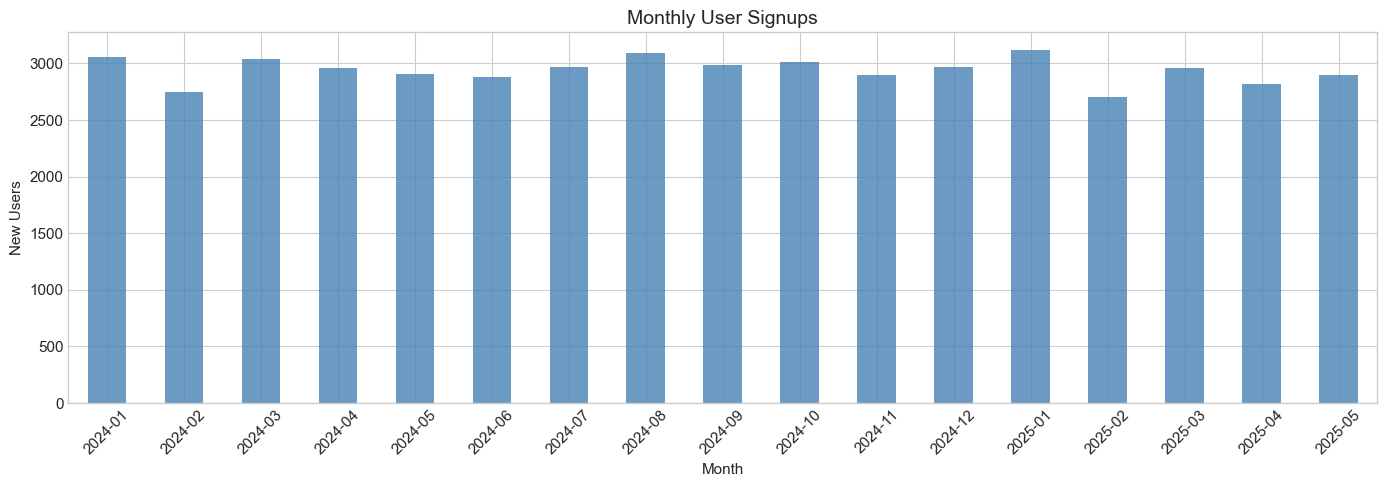

In [17]:
# Signups over time
users['signup_month'] = pd.to_datetime(users['signup_date']).dt.to_period('M')
monthly_signups = users.groupby('signup_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_signups.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Monthly User Signups', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('New Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

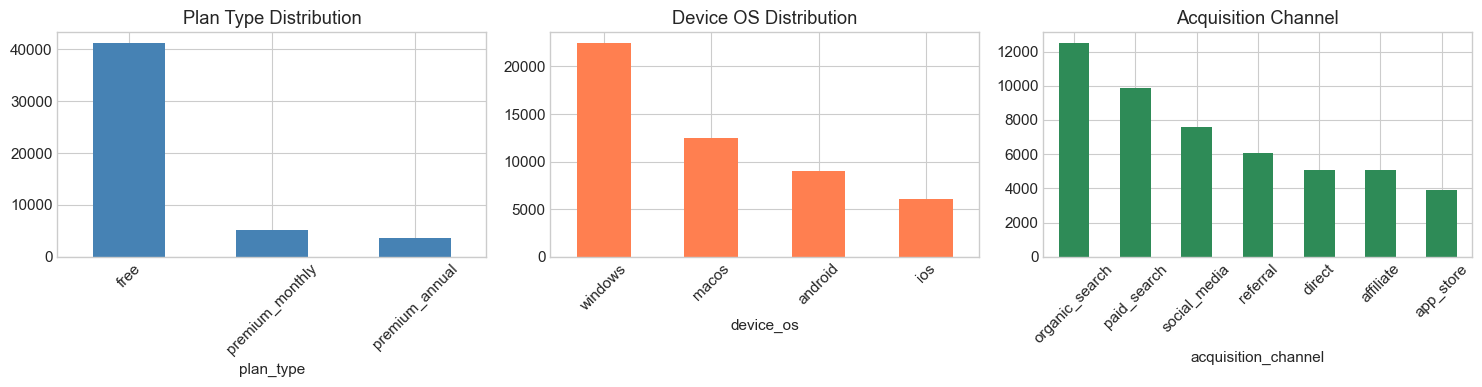

In [18]:
# Plan distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

users['plan_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Plan Type Distribution')
axes[0].tick_params(axis='x', rotation=45)

users['device_os'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Device OS Distribution')
axes[1].tick_params(axis='x', rotation=45)

users['acquisition_channel'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Acquisition Channel')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

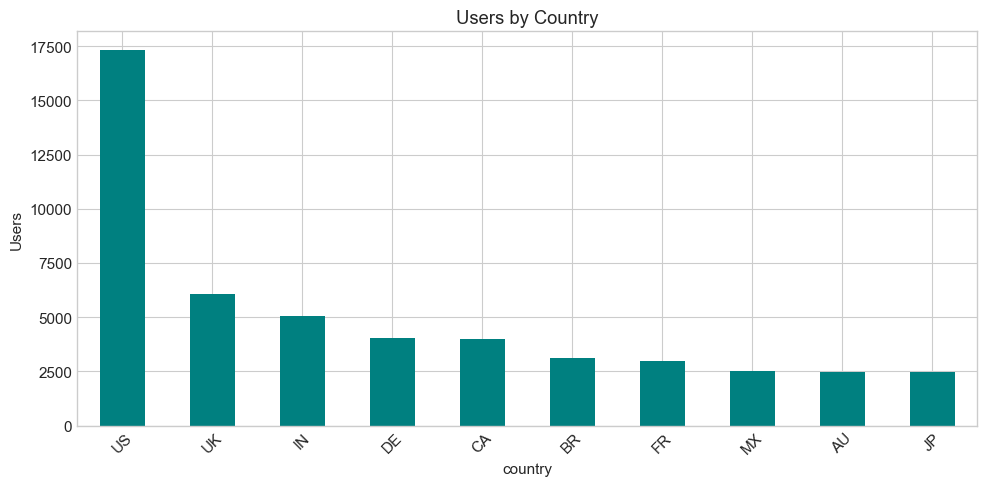


Country Distribution:
country
US   34.60
UK   12.20
IN   10.10
DE    8.00
CA    8.00
BR    6.20
FR    5.90
MX    5.00
AU    5.00
JP    5.00


In [19]:
# Geographic distribution
country_counts = users['country'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
country_counts.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Users by Country')
ax.set_ylabel('Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nCountry Distribution:")
print((country_counts / len(users) * 100).round(1).to_string())

## 4. Event Analysis (via DuckDB)

Events table is too large to load into memory. We query it directly using DuckDB.

In [20]:
# Event volume stats via DuckDB
event_stats = query_raw_table('events', """
    SELECT 
        COUNT(*) as total_events,
        COUNT(DISTINCT user_id) as unique_users,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT user_id), 1) as avg_events_per_user
    FROM {table}
""")

print("Event Statistics:")
print(f"  Total events: {event_stats['total_events'].iloc[0]:,}")
print(f"  Unique users with events: {event_stats['unique_users'].iloc[0]:,}")
print(f"  Avg events per user: {event_stats['avg_events_per_user'].iloc[0]}")

ValueError: Unknown table: 
    SELECT 
        COUNT(*) as total_events,
        COUNT(DISTINCT user_id) as unique_users,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT user_id), 1) as avg_events_per_user
    FROM {table}


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

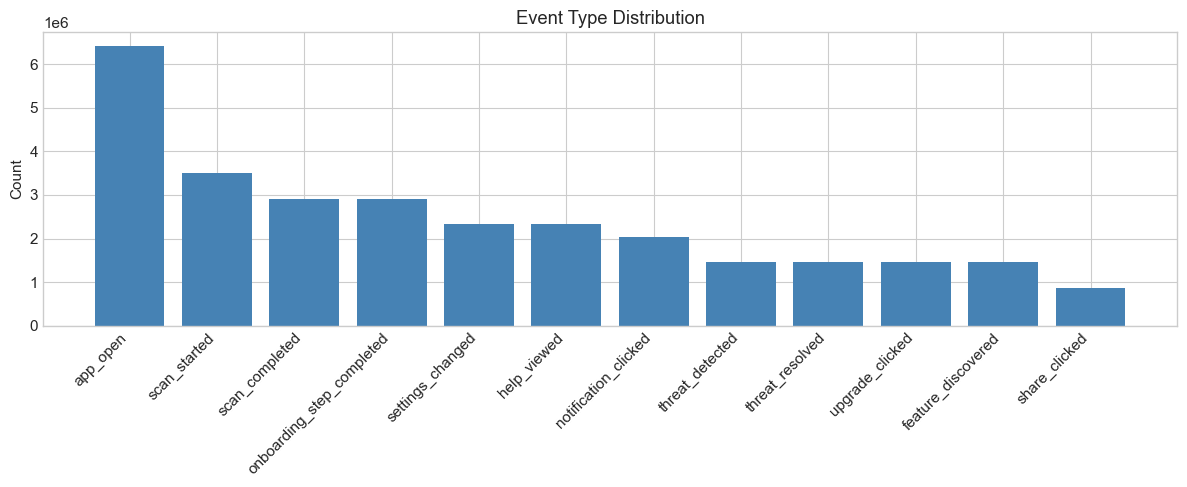

In [19]:
# Event type distribution via DuckDB
event_counts = query_raw_table('events', """
    SELECT event_type, COUNT(*) as count
    FROM {table}
    GROUP BY event_type
    ORDER BY count DESC
""")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(event_counts['event_type'], event_counts['count'], color='steelblue')
ax.set_title('Event Type Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Daily events via DuckDB
daily_events = query_raw_table('events', """
    SELECT 
        DATE_TRUNC('day', CAST(timestamp AS TIMESTAMP)) as event_date,
        COUNT(*) as count
    FROM {table}
    GROUP BY 1
    ORDER BY 1
""")

daily_events['event_date'] = pd.to_datetime(daily_events['event_date'])
daily_events = daily_events.set_index('event_date')

fig, ax = plt.subplots(figsize=(14, 5))
daily_events['count'].plot(ax=ax, alpha=0.7)
daily_events['count'].rolling(7).mean().plot(ax=ax, color='red', linewidth=2, label='7-day MA')
ax.set_title('Daily Event Volume')
ax.set_ylabel('Events')
ax.legend()
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

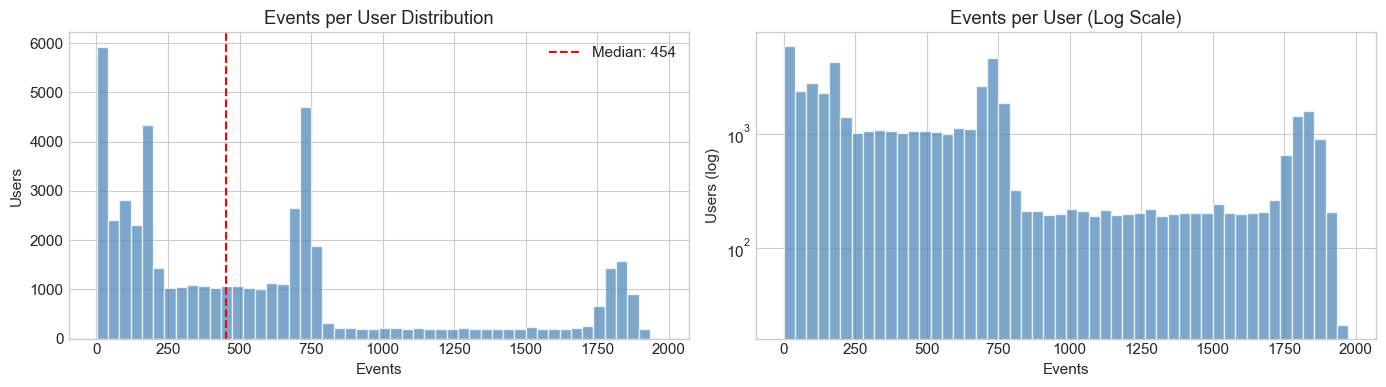

Events per user: min=1, median=454, max=1973


In [ ]:
# Events per user distribution via DuckDB
events_per_user = query_raw_table('events', """
    SELECT user_id, COUNT(*) as event_count
    FROM {table}
    GROUP BY user_id
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(events_per_user['event_count'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
median_val = events_per_user['event_count'].median()
axes[0].axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.0f}')
axes[0].set_title('Events per User Distribution')
axes[0].set_xlabel('Events')
axes[0].set_ylabel('Users')
axes[0].legend()

axes[1].hist(events_per_user['event_count'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Events per User (Log Scale)')
axes[1].set_xlabel('Events')
axes[1].set_ylabel('Users (log)')

plt.tight_layout()
plt.show()

print(f"Events per user: min={events_per_user['event_count'].min()}, median={median_val:.0f}, max={events_per_user['event_count'].max()}")

## 5. Subscription Analysis

In [21]:
# Subscription overview
print("Subscription Statistics:")
print(f"  Total subscriptions: {len(subscriptions):,}")
print(f"  Unique users: {subscriptions['user_id'].nunique():,}")
print(f"\nStatus Distribution:")
print(subscriptions['status'].value_counts().to_string())

Subscription Statistics:
  Total subscriptions: 50,000
  Unique users: 50,000

Status Distribution:
status
active       43482
cancelled     6518


In [38]:
subscriptions.columns

Index(['subscription_id', 'user_id', 'plan', 'start_date', 'end_date',
       'status', 'mrr', 'cancellation_reason'],
      dtype='object')

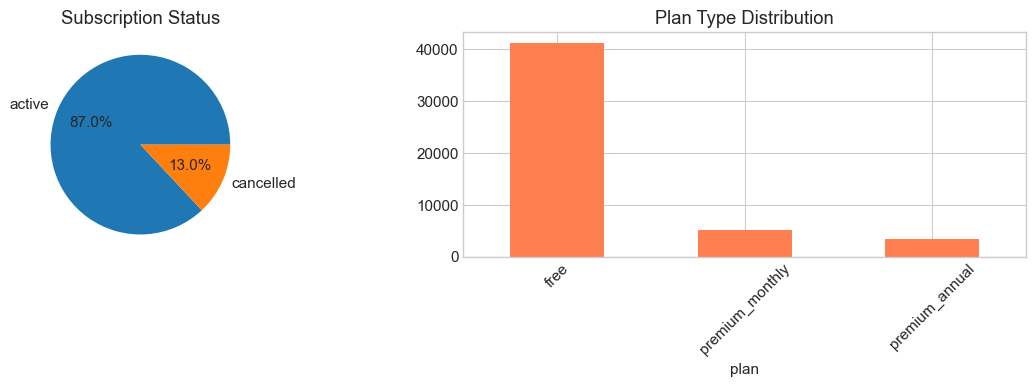

In [22]:
# Subscription status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

subscriptions['status'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('Subscription Status')
axes[0].set_ylabel('')

subscriptions['plan'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Plan Type Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# MRR analysis
active_subs = subscriptions[subscriptions['status'] == 'active']

print("MRR Statistics (Active Subscriptions):")
print(f"  Total active: {len(active_subs):,}")
print(f"  Total MRR: ${active_subs['mrr'].sum():,.2f}")
print(f"  Avg MRR: ${active_subs['mrr'].mean():.2f}")
print(f"\nMRR by Plan:")
print(active_subs.groupby('plan')['mrr'].agg(['count', 'sum', 'mean']).round(2).to_string())

MRR Statistics (Active Subscriptions):
  Total active: 43,482
  Total MRR: $75,989.04
  Avg MRR: $1.75

MRR by Plan:
                 count      sum  mean
plan                                 
free             35186     0.00  0.00
premium_annual    3444 27517.56  7.99
premium_monthly   4852 48471.48  9.99


In [24]:
# Churn analysis
cancelled_subs = subscriptions[subscriptions['status'] == 'cancelled']

print(f"Cancelled Subscriptions: {len(cancelled_subs):,}")
print(f"Churn Rate: {len(cancelled_subs) / len(subscriptions) * 100:.1f}%")

if 'cancellation_reason' in cancelled_subs.columns:
    print("\nCancellation Reasons:")
    print(cancelled_subs['cancellation_reason'].value_counts().to_string())

Cancelled Subscriptions: 6,518
Churn Rate: 13.0%

Cancellation Reasons:
cancellation_reason
not_using              2512
price                  1993
switched_competitor    1198
technical_issues        815


## 6. Experiment Coverage

In [25]:
# Experiments overview
print("Experiments:")
display(experiments)

Experiments:


,experiment_id,experiment_name,start_date,end_date,status,variants,allocation,primary_metric,targeting
0,exp_001,new_onboarding_flow,2024-03-01,2024-05-31,completed,"['control', 'treatment']","[0.5, 0.5]",activated,all_new_users
1,exp_002,threat_explainer_v2,2024-06-01,2024-08-31,completed,"['control', 'treatment']","[0.5, 0.5]",viewed_help,all_users
2,exp_003,premium_upsell_timing,2024-09-01,2024-11-30,completed,"['day_7_upsell', 'day_3_upsell']","[0.5, 0.5]",converted_to_premium,free_users
3,exp_004,real_time_protection_default,2024-11-01,2025-02-28,completed,"['rollout_group', 'control_group']","[0.5, 0.5]",threat_resolved,geo_based


In [26]:
# Assignment distribution
print("Experiment Assignments:")
assignment_summary = exp_assignments.groupby(['experiment_id', 'variant']).size().unstack(fill_value=0)
display(assignment_summary)

print("\nVariant Balance Check:")
for exp_id in exp_assignments['experiment_id'].unique():
    exp_data = exp_assignments[exp_assignments['experiment_id'] == exp_id]
    balance = exp_data['variant'].value_counts(normalize=True) * 100
    print(f"  {exp_id}: {balance.to_dict()}")

Experiment Assignments:


variant,control,control_group,day_3_upsell,day_7_upsell,rollout_group,treatment
experiment_id,,,,,,
exp_001,4356,0,0,0,0,4553
exp_002,4466,0,0,0,0,4465
exp_003,0,0,3632,3556,0,0
exp_004,0,6696,0,0,4987,0



Variant Balance Check:
  exp_001: {'treatment': 51.105623526770685, 'control': 48.894376473229315}
  exp_002: {'control': 50.0055984772142, 'treatment': 49.9944015227858}
  exp_003: {'day_3_upsell': 50.528658875904284, 'day_7_upsell': 49.471341124095716}
  exp_004: {'control_group': 57.31404604981597, 'rollout_group': 42.68595395018403}


## 7. Pattern Validation (Embedded Insights)

### 7.1 Onboarding Impact on Churn

**Expected:** Users with <3 scans in week 1 have 2-3x higher churn

In [27]:
# Calculate first week scans per user via DuckDB
users_with_dates = users.copy()
users_with_dates['signup_date'] = pd.to_datetime(users_with_dates['signup_date'])

# Register users for DuckDB join
con = duckdb.connect()
con.register('users_df', users_with_dates[['user_id', 'signup_date']])

# Query first week scans
first_week_scans = con.execute(f"""
    SELECT 
        e.user_id,
        COUNT(*) as week1_scans
    FROM read_parquet('{EVENTS_PATH}') e
    JOIN users_df u ON e.user_id = u.user_id
    WHERE e.event_type = 'scan_completed'
      AND CAST(e.timestamp AS TIMESTAMP) <= u.signup_date + INTERVAL '7 days'
    GROUP BY e.user_id
""").df()

con.close()
print(f"Users with first week scans: {len(first_week_scans):,}")

NameError: name 'EVENTS_PATH' is not defined

In [49]:
users_analysis.head()

,user_id,signup_date,plan_type,country,device_os,acquisition_channel,email_domain,signup_month,week1_scans,onboarded,churned
0,user_000000,2024-04-12,free,US,ios,referral,yahoo.com,2024-04,0.00,False,True
1,user_000001,2025-03-11,free,DE,android,paid_search,outlook.com,2025-03,0.00,False,True
2,user_000002,2024-09-27,free,UK,windows,social_media,yahoo.com,2024-09,0.00,False,False
3,user_000003,2024-04-16,free,US,windows,organic_search,gmail.com,2024-04,1.00,False,False
4,user_000004,2024-03-12,free,US,windows,paid_search,hotmail.com,2024-03,2.00,False,False


In [28]:
# Build analysis dataframe
users_analysis = users_with_dates.merge(first_week_scans, on='user_id', how='left')
users_analysis['week1_scans'] = users_analysis['week1_scans'].fillna(0)
users_analysis['onboarded'] = users_analysis['week1_scans'] >= 3

# Get churn status
user_churn = subscriptions.groupby('user_id').agg({
    'status': lambda x: 'cancelled' in x.values
}).reset_index()
user_churn.columns = ['user_id', 'churned']

users_analysis = users_analysis.merge(user_churn, on='user_id', how='left')
users_analysis['churned'] = users_analysis['churned'].fillna(False)

# Compare churn rates
churn_by_onboarding = users_analysis.groupby('onboarded')['churned'].mean() * 100

print("Churn Rate by Onboarding Status:")
print(f"  Not onboarded (<3 scans week 1): {churn_by_onboarding.get(False, 0):.1f}%")
print(f"  Onboarded (>=3 scans week 1):    {churn_by_onboarding.get(True, 0):.1f}%")
ratio = churn_by_onboarding.get(False, 1) / max(churn_by_onboarding.get(True, 1), 0.01)
print(f"\n  Ratio: {ratio:.1f}x higher churn for non-onboarded")

NameError: name 'first_week_scans' is not defined

### 7.2 Feature Adoption Impact

**Expected:** Users with `real_time_protection` have ~40% lower churn

In [52]:
# Check RTP adoption
rtp_users = feature_usage[feature_usage['feature_name'] == 'real_time_protection']['user_id'].unique()
users_analysis['has_rtp'] = users_analysis['user_id'].isin(rtp_users)

churn_by_rtp = users_analysis.groupby('has_rtp')['churned'].mean() * 100

print("Churn Rate by Real-Time Protection:")
print(f"  Without RTP: {churn_by_rtp.get(False, 0):.1f}%")
print(f"  With RTP:    {churn_by_rtp.get(True, 0):.1f}%")
reduction = (1 - churn_by_rtp.get(True, 0) / max(churn_by_rtp.get(False, 1), 0.01)) * 100
print(f"\n  Reduction: {reduction:.0f}% lower churn with RTP")

Churn Rate by Real-Time Protection:
  Without RTP: 27.3%
  With RTP:    8.6%

  Reduction: 69% lower churn with RTP


### 7.3 Cohort Analysis Preview

In [53]:
# Churn by signup quarter
users_analysis['signup_quarter'] = pd.to_datetime(users_analysis['signup_date']).dt.quarter
churn_by_quarter = users_analysis.groupby('signup_quarter')['churned'].mean() * 100

print("Churn Rate by Signup Quarter:")
for q, rate in churn_by_quarter.items():
    print(f"  Q{q}: {rate:.1f}%")

Churn Rate by Signup Quarter:
  Q1: 13.3%
  Q2: 13.4%
  Q3: 14.1%
  Q4: 10.9%


In [54]:
# Churn by acquisition channel
users_analysis = users_analysis.merge(
    users[['user_id', 'acquisition_channel']], 
    on='user_id', 
    how='left',
    suffixes=('', '_dup')
)
churn_by_channel = users_analysis.groupby('acquisition_channel')['churned'].mean() * 100

print("Churn Rate by Acquisition Channel:")
print(churn_by_channel.sort_values().to_string())

Churn Rate by Acquisition Channel:
acquisition_channel
referral          9.48
organic_search   12.05
app_store        12.50
direct           12.63
paid_search      13.74
social_media     14.47
affiliate        17.03


## 8. Key Findings Summary

In [55]:
print("="*60)
print("SECUREFLOW ANALYTICS - EDA SUMMARY")
print("="*60)

print("\n DATA OVERVIEW")
print(f"  Users: {len(users):,}")
print(f"  Events: {events_count:,}")
print(f"  Subscriptions: {len(subscriptions):,}")

print("\n REVENUE")
print(f"  Active subscriptions: {len(active_subs):,}")
print(f"  Total MRR: ${active_subs['mrr'].sum():,.0f}")
print(f"  Churn rate: {len(cancelled_subs)/len(subscriptions)*100:.1f}%")

print("\n VALIDATED PATTERNS")
print(f"  Onboarding impact: {ratio:.1f}x higher churn for non-onboarded")
print(f"  RTP feature: {reduction:.0f}% lower churn")
print(f"  Q4 cohort shows lower churn")

print("\n NEXT STEPS (Phase 2)")
print("  1. Build activation & retention funnels")
print("  2. Cohort analysis by signup month & channel")
print("  3. Feature adoption journey mapping")
print("  4. LTV calculation by segment")

SECUREFLOW ANALYTICS - EDA SUMMARY

 DATA OVERVIEW
  Users: 50,000
  Events: 29,126,215
  Subscriptions: 50,000

 REVENUE
  Active subscriptions: 43,482
  Total MRR: $75,989
  Churn rate: 13.0%

 VALIDATED PATTERNS
  Onboarding impact: 6.5x higher churn for non-onboarded
  RTP feature: 69% lower churn
  Q4 cohort shows lower churn

 NEXT STEPS (Phase 2)
  1. Build activation & retention funnels
  2. Cohort analysis by signup month & channel
  3. Feature adoption journey mapping
  4. LTV calculation by segment
